In [2]:
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt 
from torchvision import datasets , transforms
import random
import glob
from pathlib import Path
import numpy as np 
import seaborn as sns
from torch.utils.data import DataLoader


In [3]:
print(torch.__version__)
device = "CUDA" if torch.cuda.is_available() else "CPU"
print(device)

2.7.1+cu118
CUDA


## Loading the Dataset

In [4]:
train_dir = r"D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set"
test_dir = r"D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\test_set\test_set"
train_dir,test_dir


('D:\\Users\\DEBJIT DAS\\PetVision Classifier\\Dataset\\training_set\\training_set',
 'D:\\Users\\DEBJIT DAS\\PetVision Classifier\\Dataset\\test_set\\test_set')

## Understanding the Dataset

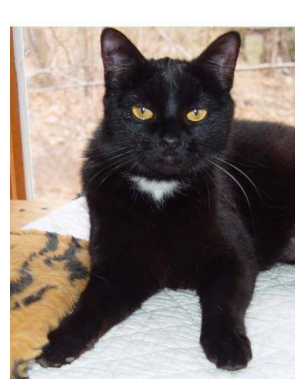

In [5]:
image = Image.open(r"D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set\cats\cat.3626.jpg")
plt.imshow(image)
plt.axis("off")
plt.show()

Image path : D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set\dogs\dog.2111.jpg
Image Class : dogs
Image Height : 374
Image Width : 500


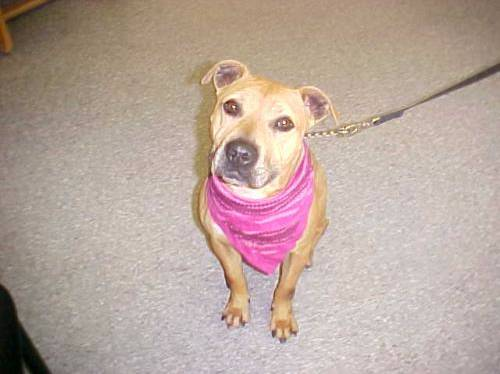

In [6]:
random.seed(42)
image_path_list = glob.glob(
    r'D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set\*/*.jpg'
)
random_image_path = random.choice(image_path_list)
image_class = Path(random_image_path).parent.stem



img = Image.open(random_image_path)
print(f"Image path : {random_image_path}")
print(f"Image Class : {image_class}")
print(f"Image Height : {img.height}")
print(f"Image Width : {img.width}")
img


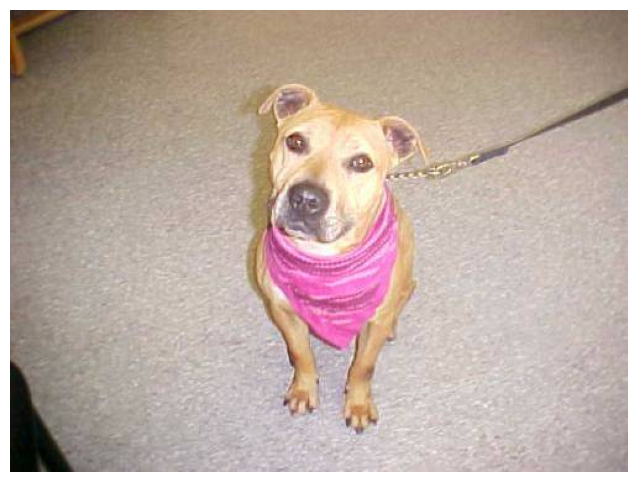

In [7]:
sns.set_theme()
image_to_array = np.array(img)
plt.figure(figsize=(8,6))
plt.imshow(image_to_array)
plt.axis(False)
plt.show()

## Transforming Data

In [8]:
image_width = 128
image_height = 128

image_size = (image_width,image_height)

transform_images = transforms.Compose([
    transforms.Resize(size=image_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

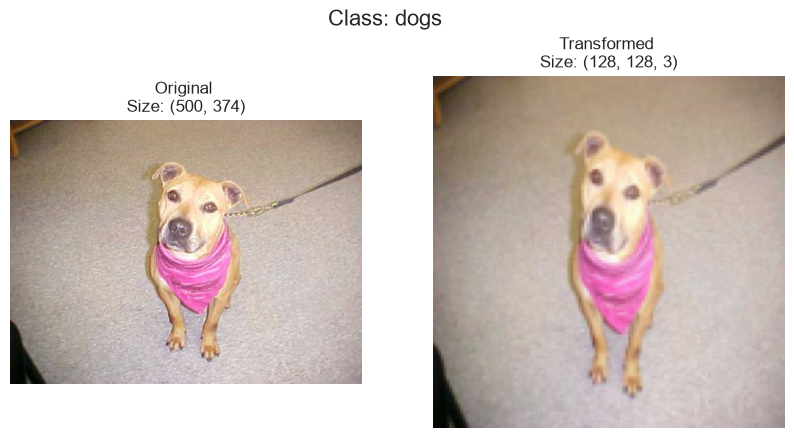

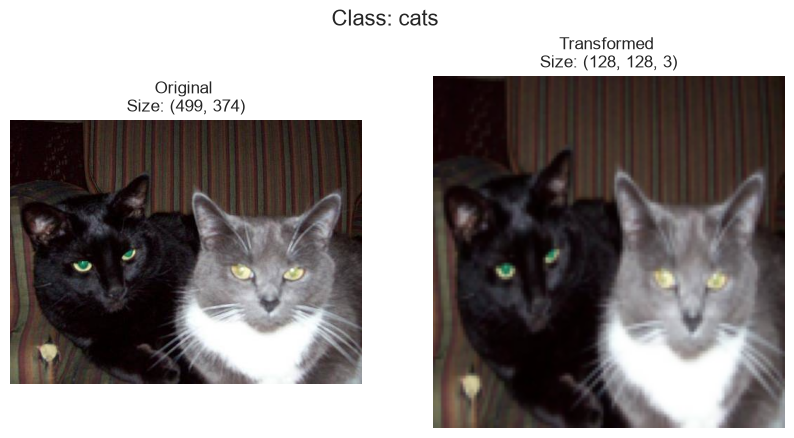

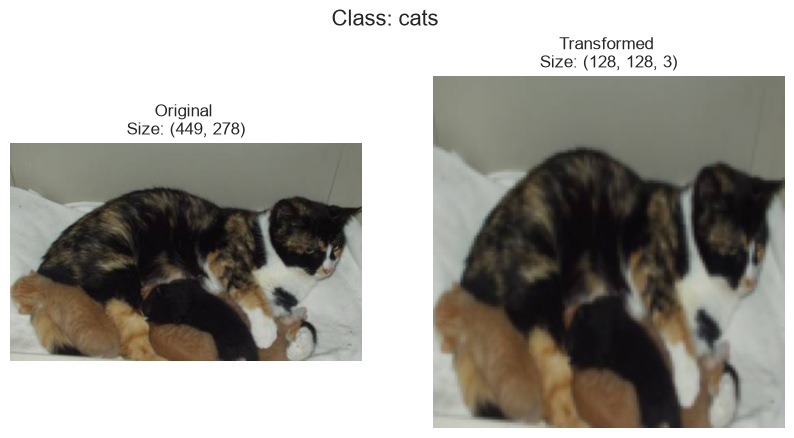

In [9]:

def transform_all_images(image_paths, transform, n=3,seed = 42):
    random.seed(seed)
    sampled_paths = random.sample(image_paths, k=min(n, len(image_paths)))
    for img_path in sampled_paths:
        with Image.open(img_path) as f:
            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            transformed = transform(f)  
            transformed = transformed.permute(1, 2, 0).numpy()  
            ax[1].imshow(transformed)
            ax[1].set_title(f"Transformed \nSize: {transformed.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {Path(img_path).parent.stem}", fontsize=16)
            plt.show()

transform_all_images(image_path_list, transform=transform_images, n=3)

##  Loading Image Data

In [10]:
train_data = datasets.ImageFolder(root=train_dir, transform=transform_images,target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=transform_images)
print(f"Train Data {train_data}\n Test Data {test_data}")

Train Data Dataset ImageFolder
    Number of datapoints: 8005
    Root location: D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
 Test Data Dataset ImageFolder
    Number of datapoints: 2021
    Root location: D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\test_set\test_set
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [14]:
print(f"Class name : {train_data.classes}")
print(f"Class name : {train_data.class_to_idx}")
print(f"The Lenght of Traning and Test Data Set  :",len(train_data),len(test_data))


Class name : ['cats', 'dogs']
Class name : {'cats': 0, 'dogs': 1}
The Lenght of Traning and Test Data Set  : 8005 2021
